# Emotion Detection Analysis
Analyze lyrics using GoEmotions (28 emotions) with full-text chunking.

In [1]:
import numpy as np
import pandas as pd
import re
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/home/lmafra/projects/Artist-Sentiment-Analysis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Imports

## Configuration

In [2]:
OUTPUT_DIR = Path("./output")

lyrics_df = pd.read_csv(OUTPUT_DIR / "lyrics.csv", encoding='utf-8-sig')
print(f"Loaded {len(lyrics_df)} songs")
lyrics_df.head()

Loaded 126 songs


,music_title,genius_title,lyrics,year,album
0,wacced out murals,wacced out murals,[Intro: Deyra Barrera]\nSiento aquí tu presenc...,NaN,GNX
1,squabble up,squabble up,[Intro: Kendrick Lamar]\nGod knows\nI am reinc...,NaN,GNX
2,luther (with sza),KENDRICK LAMAR & SZA luther (REMIX) FEATURING ...,[Intro]\nIf this world were mine\n\n[Verse 1: ...,NaN,GNX
3,man at the garden,man at the garden,[Verse 1]\nTwice emotional stability\nOf sound...,NaN,GNX
4,hey now (feat. dody6),Kendrick Lamar - hey now ft. Dody6 (Traducción...,"[Letra de ""Kendrick Lamar - hey now""]\n\n[Intr...",NaN,GNX


In [3]:
print(f"Missing values:\n{lyrics_df.isnull().sum()}")
print(f"\nOriginal shape: {lyrics_df.shape}")

lyrics_df = lyrics_df.dropna(subset=['lyrics']).drop_duplicates(subset=['music_title']).reset_index(drop=True)
print(f"After cleanup: {lyrics_df.shape}")

Missing values:
music_title       0
genius_title      0
lyrics            0
year            126
album             0
dtype: int64

Original shape: (126, 5)
After cleanup: (126, 5)


### Load and Clean Data

## Lyrics Preprocessing

### Clean lyrics (remove section markers, normalize whitespace)

In [4]:
def clean_lyrics(text, keep_sections=True):
    """Clean lyrics, optionally preserving section markers."""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    if not keep_sections:
        text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

lyrics_df['lyrics_clean'] = lyrics_df['lyrics'].apply(lambda x: clean_lyrics(x, keep_sections=True))
lyrics_df['lyrics_no_sections'] = lyrics_df['lyrics'].apply(lambda x: clean_lyrics(x, keep_sections=False))
print(f"Example lyrics with sections (first 500 chars):\n{lyrics_df['lyrics_clean'].iloc[0][:500]}")

Example lyrics with sections (first 500 chars):
[Intro: Deyra Barrera] Siento aquí tu presencia La noche de anoche Y nos ponemos a llorar [Verse 1] Yesterday somebody whacked out my mural That energy'll make you niggas move to Europe But it's regular for me, yeah, that's for sure The love and hate is definite without a cure All this talk is bitch-made, that's on my Lord I'll kill 'em all before I let 'em kill my joy I done been through it all, what you endure? It used to be fuck that nigga, but now it's plural Fuck everybody, that's on my bod


In [5]:
lyrics_df['lyrics_length'] = lyrics_df['lyrics_clean'].apply(len)
print(f"Lyrics length stats:\n{lyrics_df['lyrics_length'].describe()}")

Lyrics length stats:
count       126.000000
mean       6407.103175
std       13606.073624
min         665.000000
25%        3087.750000
50%        3862.000000
75%        4702.000000
max      111317.000000
Name: lyrics_length, dtype: float64


### Calculate Lyrics Length

In [6]:
lyrics_df.head()

,music_title,genius_title,lyrics,year,album,lyrics_clean,lyrics_no_sections,lyrics_length
0,wacced out murals,wacced out murals,[Intro: Deyra Barrera]\nSiento aquí tu presenc...,NaN,GNX,[Intro: Deyra Barrera] Siento aquí tu presenci...,Siento aquí tu presencia La noche de anoche Y ...,5013
1,squabble up,squabble up,[Intro: Kendrick Lamar]\nGod knows\nI am reinc...,NaN,GNX,[Intro: Kendrick Lamar] God knows I am reincar...,God knows I am reincarnated I was stargazin' L...,2853
2,luther (with sza),KENDRICK LAMAR & SZA luther (REMIX) FEATURING ...,[Intro]\nIf this world were mine\n\n[Verse 1: ...,NaN,GNX,[Intro] If this world were mine [Verse 1: Kend...,"If this world were mine Hey, Roman numeral sev...",4564
3,man at the garden,man at the garden,[Verse 1]\nTwice emotional stability\nOf sound...,NaN,GNX,[Verse 1] Twice emotional stability Of sound b...,Twice emotional stability Of sound body and tr...,2718
4,hey now (feat. dody6),Kendrick Lamar - hey now ft. Dody6 (Traducción...,"[Letra de ""Kendrick Lamar - hey now""]\n\n[Intr...",NaN,GNX,"[Letra de ""Kendrick Lamar - hey now""] [Intro: ...","Diablos, nena Me gusta Diablos Hmm Ey ahora, d...",4290


## Emotion Detection with Transformers

In [ ]:
print("Loading GoEmotions model (28 emotions)...")
emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    truncation=True,
    max_length=512
)
print("Model loaded!")

EMOTIONS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 
    'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]
print(f"Tracking {len(EMOTIONS)} emotions")

Loading GoEmotions model (28 emotions)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1878.47it/s]


Model loaded!
Tracking 27 emotions


### Load GoEmotions Model

In [8]:
def chunk_text(text, chunk_size=400, overlap=50):
    """Split text into overlapping chunks for full coverage."""
    if not text or len(text) < chunk_size:
        return [text] if text else []
    chunks = []
    step = chunk_size - overlap
    for i in range(0, len(text), step):
        chunk = text[i:i + chunk_size]
        if len(chunk) >= 50:
            chunks.append(chunk)
    return chunks

def analyze_emotions(text, top_n=5):
    """Analyze emotions across all chunks, return top N with aggregated scores."""
    if not text or len(text) < 10:
        return [('', 0.0)] * top_n, {}
    
    chunks = chunk_text(text)
    all_scores = defaultdict(list)
    
    for chunk in chunks:
        try:
            results = emotion_classifier(chunk)[0]
            for item in results:
                all_scores[item['label']].append(item['score'])
        except Exception:
            continue
    
    if not all_scores:
        return [('', 0.0)] * top_n, {}
    
    avg_scores = {k: np.mean(v) for k, v in all_scores.items()}
    sorted_emotions = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)
    sorted_emotions = [e for e in sorted_emotions if e[0] != 'neutral']  # Filter neutral
    
    top_emotions = sorted_emotions[:top_n]
    while len(top_emotions) < top_n:
        top_emotions.append(('', 0.0))
    
    return top_emotions, avg_scores

test_emotions, _ = analyze_emotions("I love this song, it makes me so happy and excited!")
print(f"Test emotions: {test_emotions}")

Test emotions: [('love', np.float64(0.679211437702179)), ('joy', np.float64(0.3999812602996826)), ('excitement', np.float64(0.3770076036453247)), ('admiration', np.float64(0.0494181253015995)), ('approval', np.float64(0.016432316973805428))]


### Section Parsing Functions

In [9]:
def parse_sections(lyrics):
    """Parse lyrics into sections based on markers like [Verse], [Chorus]."""
    if not lyrics or pd.isna(lyrics):
        return [{'type': 'full', 'text': ''}]
    
    pattern = r'\[([^\]]+)\]'
    parts = re.split(pattern, lyrics)
    
    sections = []
    current_type = 'intro'
    for j, part in enumerate(parts):
        if j % 2 == 1:  # Section header
            header = part.split(':')[0].strip().lower()
            # Normalize section types
            if 'verse' in header:
                current_type = 'verse'
            elif 'chorus' in header or 'hook' in header or 'refrain' in header:
                current_type = 'chorus'
            elif 'bridge' in header:
                current_type = 'bridge'
            elif 'outro' in header:
                current_type = 'outro'
            elif 'intro' in header:
                current_type = 'intro'
            elif 'pre' in header:
                current_type = 'pre-chorus'
            else:
                current_type = header[:20]
        else:
            text = part.strip()
            if text and len(text) > 20:
                sections.append({'type': current_type, 'text': text})
    
    if not sections:
        return [{'type': 'full', 'text': lyrics}]
    return sections

def analyze_song_sections(lyrics, top_n=3):
    """Analyze emotions for each section of a song."""
    sections = parse_sections(lyrics)
    results = []
    for section in sections:
        emotions, scores = analyze_emotions(section['text'], top_n=top_n)
        results.append({
            'section_type': section['type'],
            'section_num': len([r for r in results if r['section_type'] == section['type']]) + 1,
            'text_len': len(section['text']),
            'dominant_emotion': emotions[0][0] if emotions else '',
            'dominant_score': emotions[0][1] if emotions else 0,
            'top_emotions': emotions,
            'all_scores': scores
        })
    return results

# Test section parsing
test_lyrics = "[Verse 1]\nI'm feeling sad today\n[Chorus]\nBut the music makes me happy"
test_sections = parse_sections(test_lyrics)
print(f"Test sections: {len(test_sections)} found")
for s in test_sections:
    print(f"  {s['type']}: {s['text'][:50]}...")

Test sections: 2 found
  verse: I'm feeling sad today...
  chorus: But the music makes me happy...


In [10]:
print("Analyzing emotions for all songs (full lyrics with chunking)...")
tqdm.pandas(desc="Analyzing")

results = lyrics_df['lyrics_clean'].progress_apply(analyze_emotions)
lyrics_df['top_emotions'] = results.apply(lambda x: x[0])
lyrics_df['all_emotions'] = results.apply(lambda x: x[1])

for i in range(1, 6):
    lyrics_df[f'emotion_{i}'] = lyrics_df['top_emotions'].apply(
        lambda x: x[i-1][0] if len(x) > i-1 else ''
    )
    lyrics_df[f'emotion_{i}_score'] = lyrics_df['top_emotions'].apply(
        lambda x: x[i-1][1] if len(x) > i-1 else 0.0
    )

lyrics_df.drop(columns=['top_emotions'], inplace=True)

print(f"\nDominant emotion distribution:")
print(lyrics_df['emotion_1'].value_counts().head(10))

Analyzing emotions for all songs (full lyrics with chunking)...


Analyzing: 100%|██████████| 126/126 [00:20<00:00,  6.25it/s]


Dominant emotion distribution:
emotion_1
annoyance      48
approval       17
anger          10
love           10
curiosity       8
sadness         6
confusion       5
desire          4
disapproval     3
remorse         2
Name: count, dtype: int64


### Section-Level Emotion Analysis

In [11]:
print("Analyzing emotions by section...")
tqdm.pandas(desc="Section Analysis")

lyrics_df['section_data'] = lyrics_df['lyrics_clean'].progress_apply(analyze_song_sections)
lyrics_df['section_count'] = lyrics_df['section_data'].apply(len)

# Create emotion flow string
def get_emotion_flow(sections):
    if not sections:
        return ""
    return " -> ".join([s['dominant_emotion'] for s in sections if s['dominant_emotion']])

lyrics_df['emotion_flow'] = lyrics_df['section_data'].apply(get_emotion_flow)

print(f"\nSection stats:")
print(f"  Avg sections per song: {lyrics_df['section_count'].mean():.1f}")
print(f"  Songs with 1 section: {(lyrics_df['section_count'] == 1).sum()}")
print(f"  Songs with 3+ sections: {(lyrics_df['section_count'] >= 3).sum()}")
print(f"\nExample emotion flow:")
for idx in lyrics_df[lyrics_df['section_count'] >= 3].head(3).index:
    print(f"  {lyrics_df.loc[idx, 'music_title']}: {lyrics_df.loc[idx, 'emotion_flow']}")

Analyzing emotions by section...


Section Analysis: 100%|██████████| 126/126 [00:21<00:00,  5.73it/s]


Section stats:
  Avg sections per song: 8.4
  Songs with 1 section: 5
  Songs with 3+ sections: 120

Example emotion flow:
  wacced out murals: approval -> anger -> caring -> approval -> desire -> approval -> annoyance
  squabble up: desire -> approval -> joy -> anger -> joy -> approval -> annoyance -> anger -> joy -> approval
  luther (with sza): optimism -> approval -> desire -> approval -> desire -> love -> approval


### Chunking and Analysis Functions

## Visualization

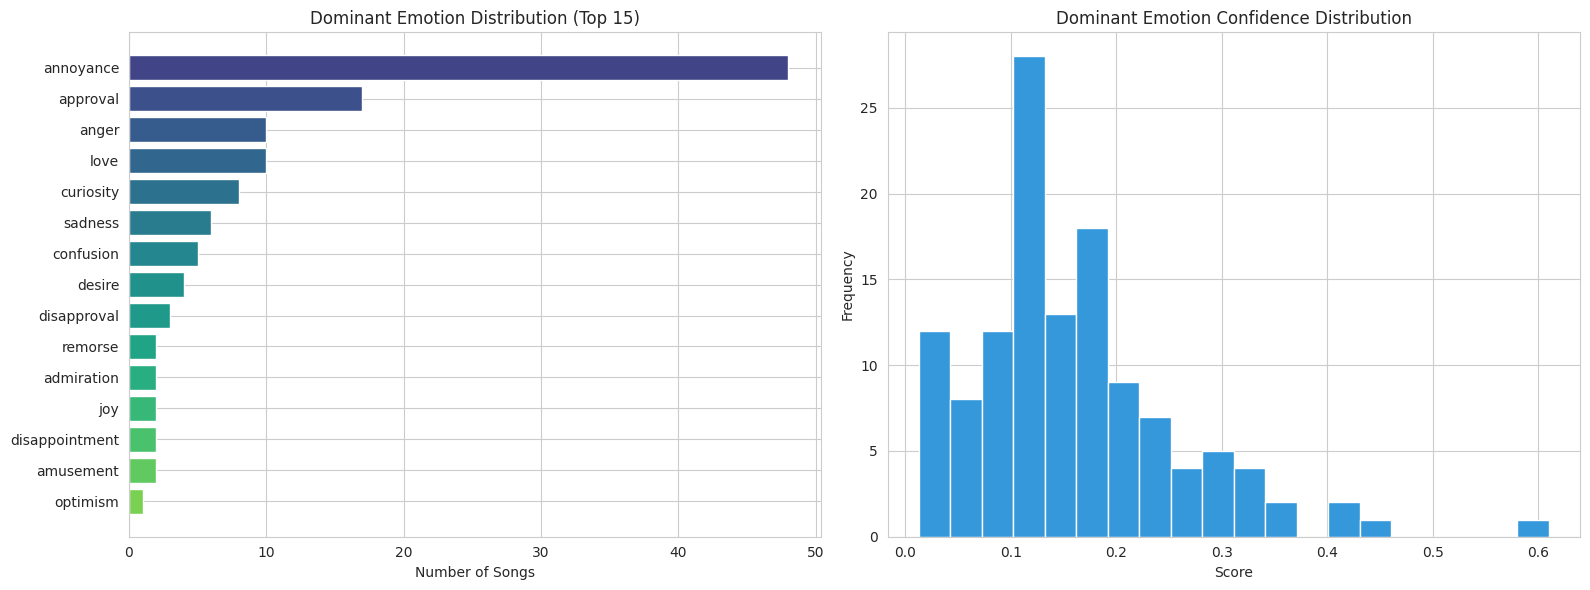

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

emotion_counts = lyrics_df['emotion_1'].value_counts().head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(emotion_counts)))
axes[0].barh(emotion_counts.index[::-1], emotion_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Dominant Emotion Distribution (Top 15)')
axes[0].set_xlabel('Number of Songs')

axes[1].hist(lyrics_df['emotion_1_score'], bins=20, color='#3498db', edgecolor='white')
axes[1].set_title('Dominant Emotion Confidence Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Emotion Flow by Section

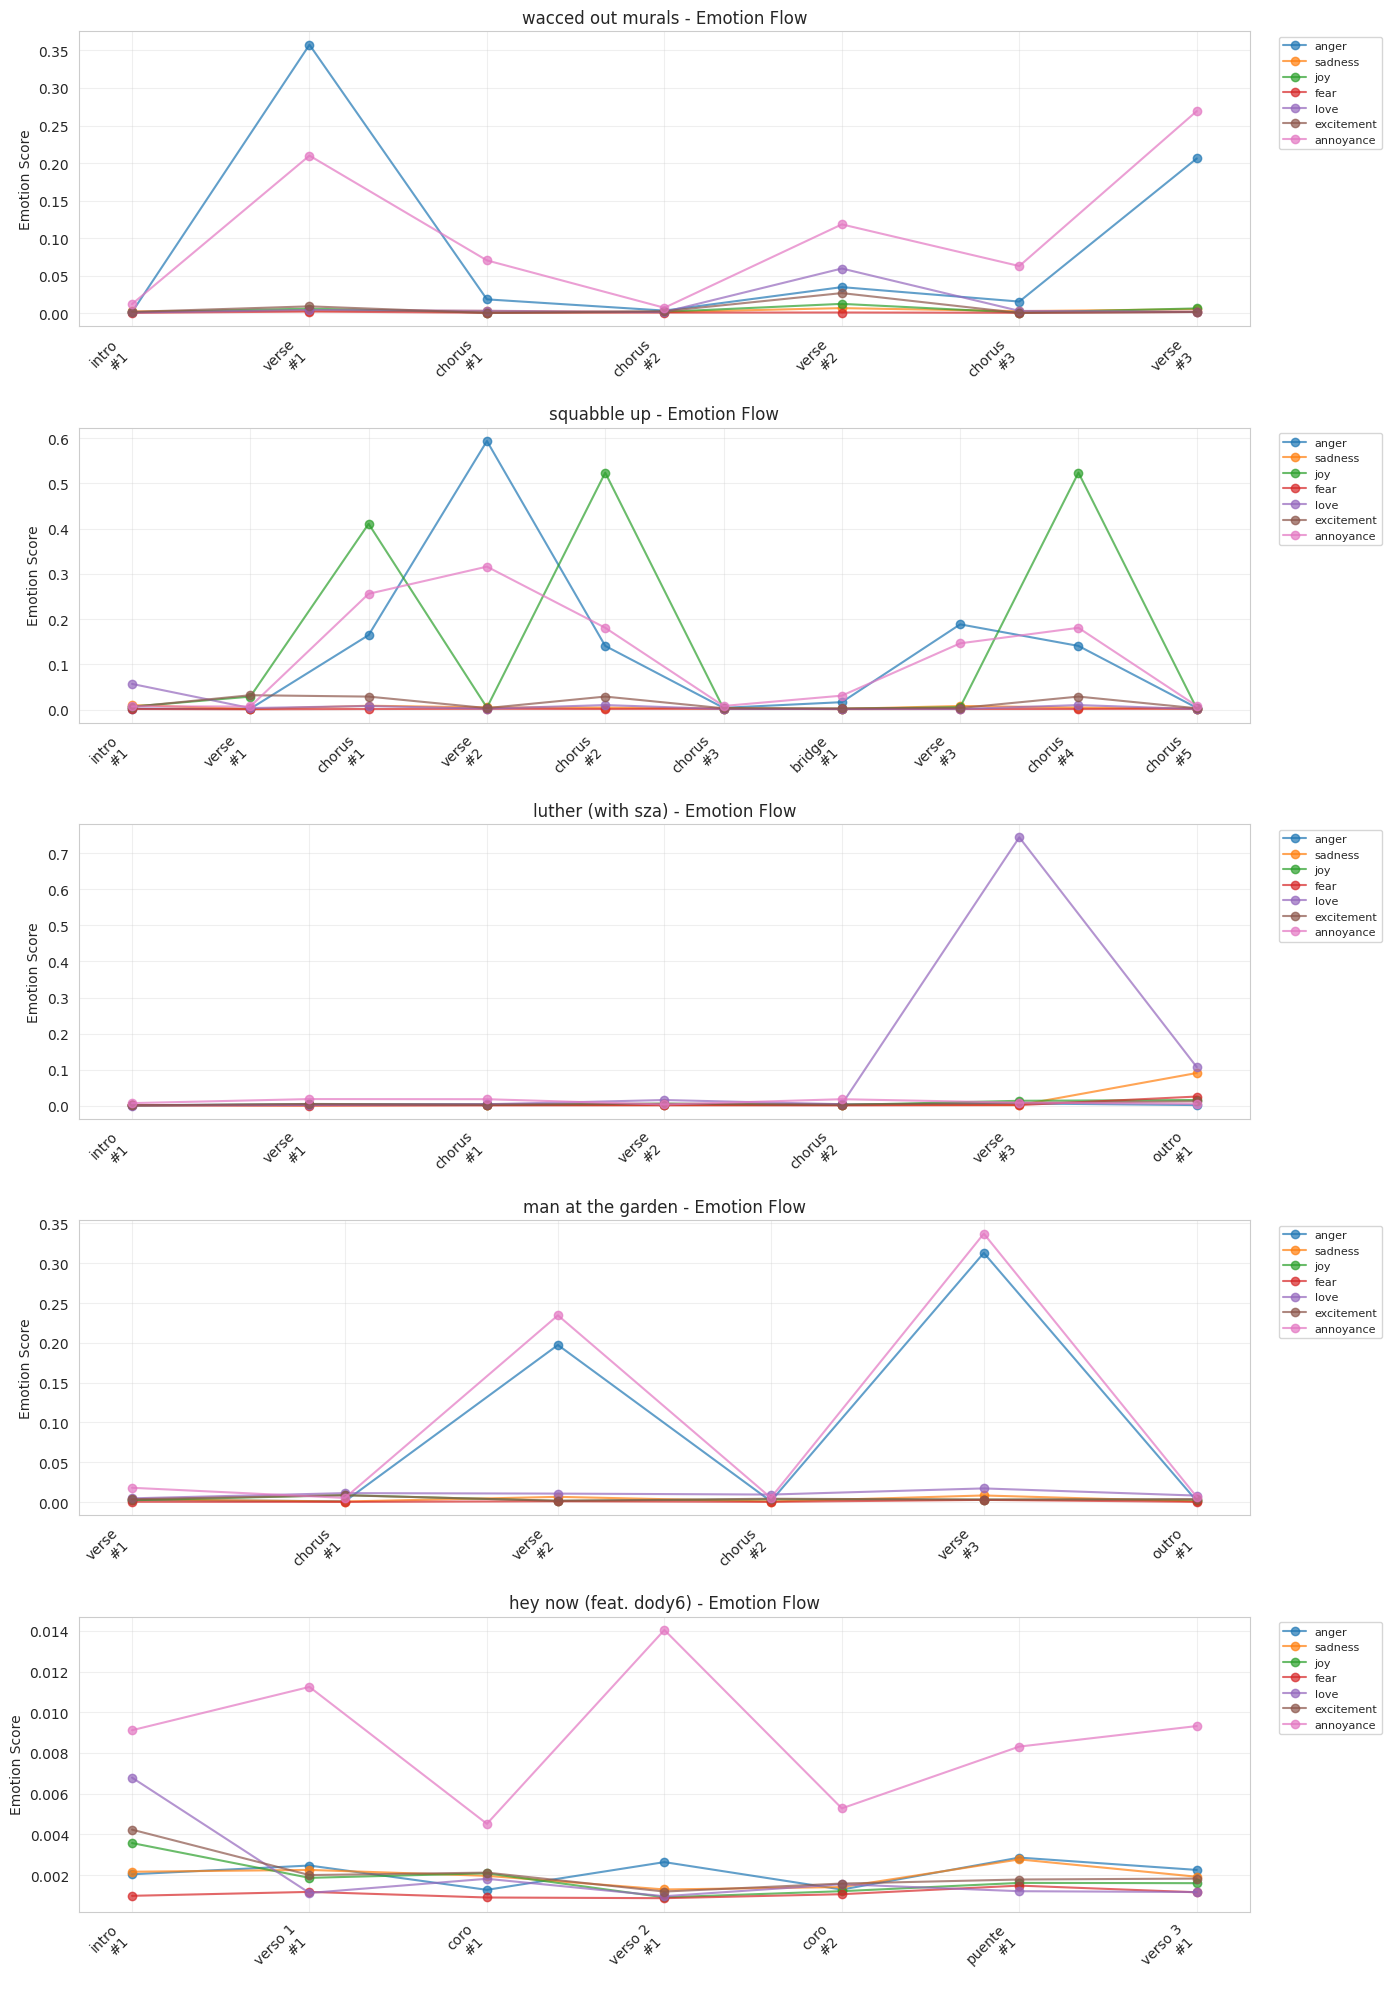

In [13]:
# Emotion Flow Visualization - Single Song Deep Dive
songs_with_sections = lyrics_df[lyrics_df['section_count'] >= 3].head(5)

if len(songs_with_sections) > 0:
    fig, axes = plt.subplots(len(songs_with_sections), 1, figsize=(14, 4*len(songs_with_sections)))
    if len(songs_with_sections) == 1:
        axes = [axes]
    
    target_emotions = ['anger', 'sadness', 'joy', 'fear', 'love', 'excitement', 'annoyance']
    
    for ax, (idx, row) in zip(axes, songs_with_sections.iterrows()):
        sections = row['section_data']
        x = range(len(sections))
        x_labels = [f"{s['section_type']}\n#{s['section_num']}" for s in sections]
        
        for emotion in target_emotions:
            y = [s['all_scores'].get(emotion, 0) for s in sections]
            ax.plot(x, y, 'o-', label=emotion, alpha=0.7)
        
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=45, ha='right')
        ax.set_ylabel('Emotion Score')
        ax.set_title(f"{row['music_title'][:40]} - Emotion Flow")
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No songs with 3+ sections found. Re-run crawler with section headers enabled.")

### Section Type Comparison

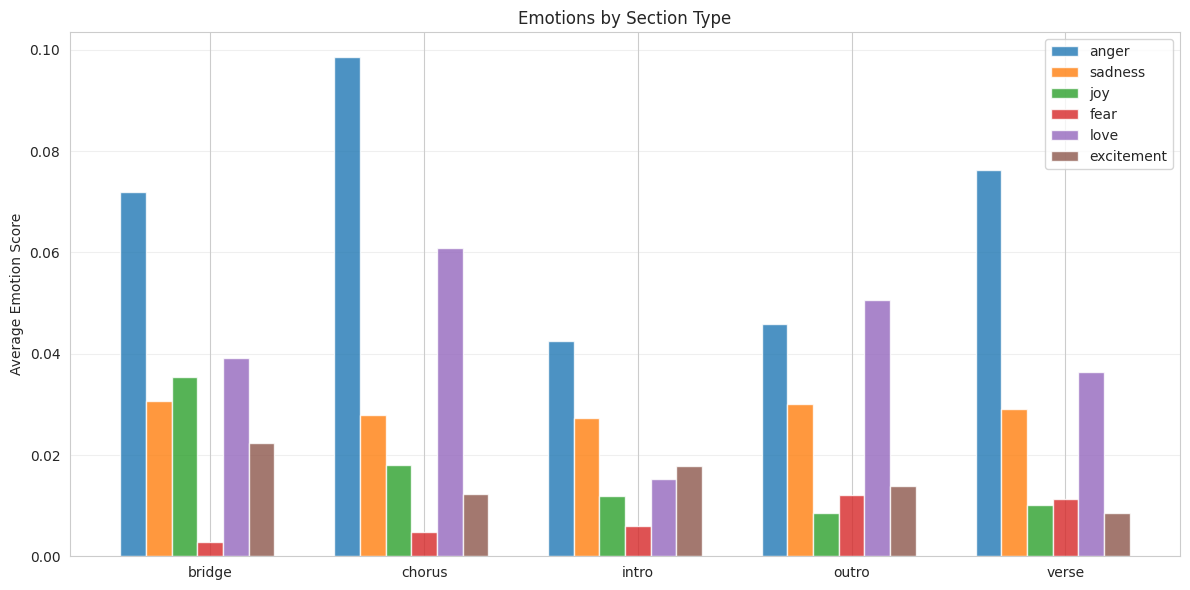


Section type counts:
section_type
chorus    324
verse     310
intro      99
outro      65
bridge     39
Name: count, dtype: int64


In [14]:
# Section Type Comparison - Average Emotions
all_sections = []
for idx, row in lyrics_df.iterrows():
    for section in row['section_data']:
        section_entry = {
            'song': row['music_title'],
            'section_type': section['section_type'],
            **section['all_scores']
        }
        all_sections.append(section_entry)

sections_df = pd.DataFrame(all_sections)

if len(sections_df) > 0:
    main_types = ['verse', 'chorus', 'bridge', 'intro', 'outro']
    sections_filtered = sections_df[sections_df['section_type'].isin(main_types)]
    
    if len(sections_filtered) > 0:
        emotions_to_plot = ['anger', 'sadness', 'joy', 'fear', 'love', 'excitement']
        available_emotions = [e for e in emotions_to_plot if e in sections_filtered.columns]
        
        if available_emotions:
            section_means = sections_filtered.groupby('section_type')[available_emotions].mean()
            
            fig, ax = plt.subplots(figsize=(12, 6))
            x = np.arange(len(section_means.index))
            width = 0.12
            
            for j, emotion in enumerate(available_emotions):
                offset = (j - len(available_emotions)/2) * width
                ax.bar(x + offset, section_means[emotion], width, label=emotion, alpha=0.8)
            
            ax.set_xticks(x)
            ax.set_xticklabels(section_means.index)
            ax.set_ylabel('Average Emotion Score')
            ax.set_title('Emotions by Section Type')
            ax.legend()
            ax.grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
            
            print(f"\nSection type counts:")
            print(sections_filtered['section_type'].value_counts())
    else:
        print("No standard section types found.")
else:
    print("No section data available.")

### Run Emotion Analysis

### Emotion Heatmap

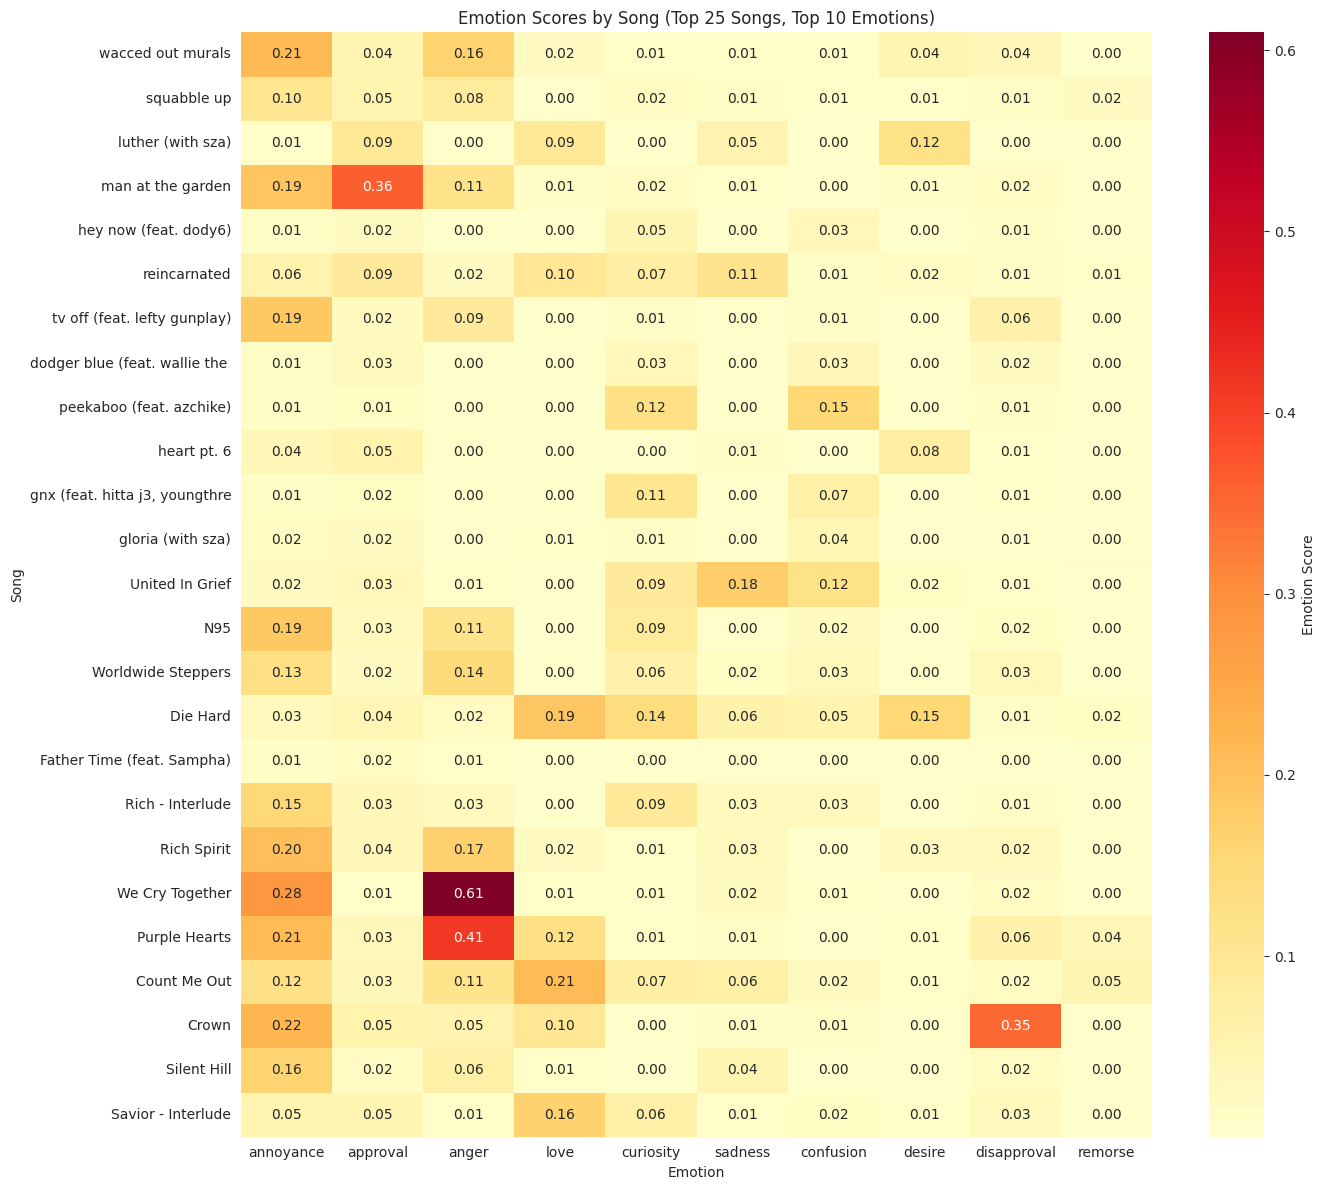

In [15]:
top_emotions_overall = lyrics_df['emotion_1'].value_counts().head(10).index.tolist()

emotion_matrix = pd.DataFrame()
for emotion in top_emotions_overall:
    emotion_matrix[emotion] = lyrics_df['all_emotions'].apply(
        lambda x: x.get(emotion, 0) if isinstance(x, dict) else 0
    )
emotion_matrix.index = lyrics_df['music_title'].str[:30]

plt.figure(figsize=(14, 12))
sns.heatmap(emotion_matrix.head(25), annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Emotion Score'})
plt.title('Emotion Scores by Song (Top 25 Songs, Top 10 Emotions)')
plt.xlabel('Emotion')
plt.ylabel('Song')
plt.tight_layout()
plt.show()

## Merge with Spotify Audio Features

### Emotion Distribution Charts

### Load and merge Spotify data

In [16]:
spotify_path = OUTPUT_DIR / "spotify.csv"
if spotify_path.exists():
    spotify_df = pd.read_csv(spotify_path)
    print(f"Loaded {len(spotify_df)} tracks from Spotify")
    
    lyrics_df['name_lower'] = lyrics_df['music_title'].str.lower().str.strip()
    spotify_df['name_lower'] = spotify_df['name'].str.lower().str.strip()
    
    merged_df = pd.merge(
        lyrics_df, spotify_df,
        on='name_lower',
        how='inner',
        suffixes=('_lyrics', '_spotify')
    )
    print(f"Merged: {len(merged_df)} tracks")
    merged_df.head()
else:
    print("Spotify data not found. Run Lyrics-Crawler.ipynb first.")
    merged_df = lyrics_df.copy()

Loaded 466 tracks from Spotify
Merged: 158 tracks


### Correlation: Audio Features vs Emotions

### Emotion Radar Chart by Album

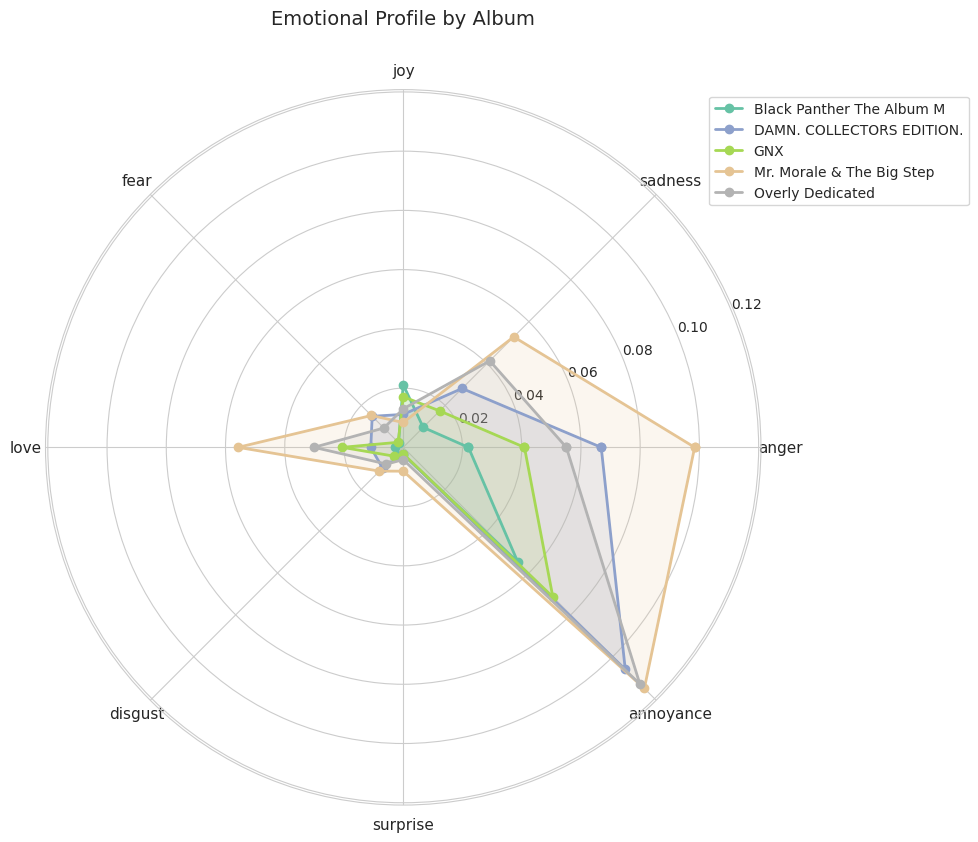

In [17]:
from math import pi

albums_with_songs = lyrics_df.groupby('album').size()
valid_albums = albums_with_songs[albums_with_songs >= 3].index.tolist()
valid_albums = [a for a in valid_albums if pd.notna(a)][:5]

radar_emotions = ['anger', 'sadness', 'joy', 'fear', 'love', 'disgust', 'surprise', 'annoyance']

album_emotion_profiles = {}
for album in valid_albums:
    album_songs = lyrics_df[lyrics_df['album'] == album]
    profile = {}
    for emotion in radar_emotions:
        scores = album_songs['all_emotions'].apply(
            lambda x: x.get(emotion, 0) if isinstance(x, dict) else 0
        )
        profile[emotion] = scores.mean()
    album_emotion_profiles[album] = profile

if album_emotion_profiles:
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    angles = [n / float(len(radar_emotions)) * 2 * pi for n in range(len(radar_emotions))]
    angles += angles[:1]
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(valid_albums)))
    
    for idx, (album, profile) in enumerate(album_emotion_profiles.items()):
        values = [profile[e] for e in radar_emotions]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=album[:25], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_emotions, size=11)
    ax.set_title('Emotional Profile by Album', size=14, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough albums with 3+ songs for radar chart.")

### Spotify Audio Features Correlation

### Emotion Co-occurrence Matrix

In [18]:
audio_features = ['valence', 'energy', 'danceability', 'acousticness', 'speechiness']
target_emotions = ['anger', 'sadness', 'joy', 'fear', 'love', 'excitement', 'annoyance']
available_features = [f for f in audio_features if f in merged_df.columns]

if available_features and 'all_emotions' in merged_df.columns:
    for emotion in target_emotions:
        merged_df[f'emo_{emotion}'] = merged_df['all_emotions'].apply(
            lambda x: x.get(emotion, 0) if isinstance(x, dict) else 0
        )
    
    emotion_cols = [f'emo_{e}' for e in target_emotions]
    corr_matrix = merged_df[available_features + emotion_cols].corr()
    corr_subset = corr_matrix.loc[available_features, emotion_cols]
    corr_subset.columns = target_emotions
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
    plt.title('Audio Features vs Lyrical Emotions Correlation')
    plt.xlabel('Emotions')
    plt.ylabel('Audio Features')
    plt.tight_layout()
    plt.show()
    
    merged_df.drop(columns=emotion_cols, inplace=True)
else:
    print("No Spotify audio features available for correlation analysis.")

No Spotify audio features available for correlation analysis.


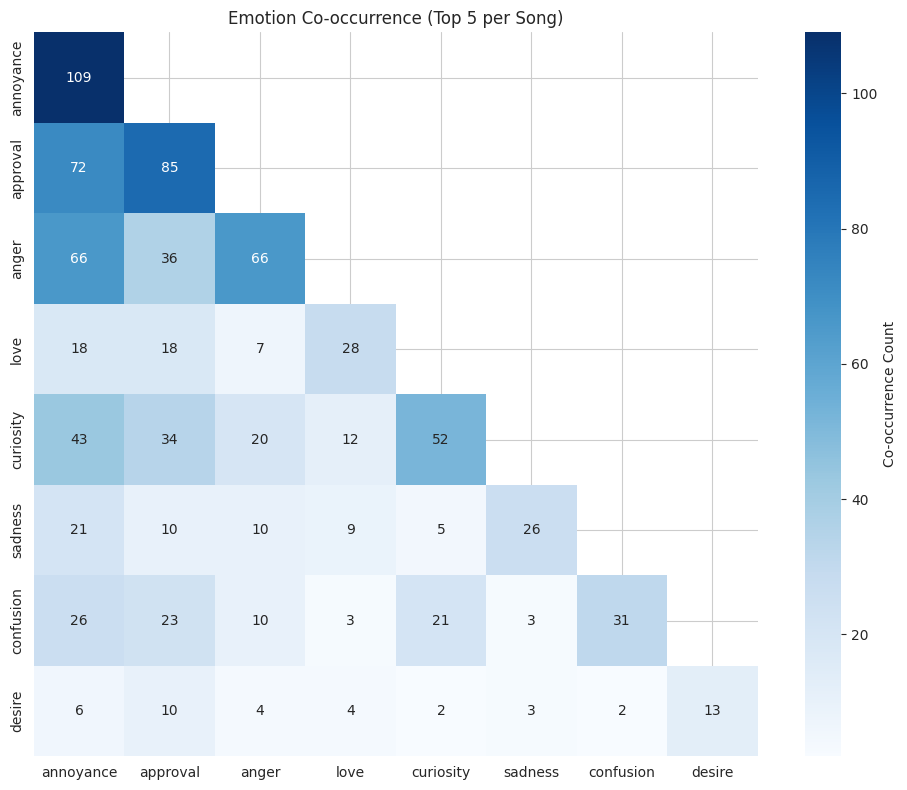

In [19]:
top_8_emotions = lyrics_df['emotion_1'].value_counts().head(8).index.tolist()

cooccur_matrix = pd.DataFrame(index=top_8_emotions, columns=top_8_emotions, dtype=float)
for e1 in top_8_emotions:
    for e2 in top_8_emotions:
        count = 0
        for _, row in lyrics_df.iterrows():
            top5 = [row[f'emotion_{i}'] for i in range(1, 6)]
            if e1 in top5 and e2 in top5:
                count += 1
        cooccur_matrix.loc[e1, e2] = count

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(cooccur_matrix, dtype=bool), k=1)
sns.heatmap(cooccur_matrix.astype(float), annot=True, fmt='.0f', cmap='Blues',
            mask=mask, square=True, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Emotion Co-occurrence (Top 5 per Song)')
plt.tight_layout()
plt.show()

## Export Results

### Save Results

In [20]:
export_cols = ['music_title', 'year', 'album', 'lyrics_length',
               'emotion_1', 'emotion_1_score', 'emotion_2', 'emotion_2_score',
               'emotion_3', 'emotion_3_score', 'emotion_4', 'emotion_4_score',
               'emotion_5', 'emotion_5_score']
lyrics_export = lyrics_df[[c for c in export_cols if c in lyrics_df.columns]]
lyrics_export.to_csv(OUTPUT_DIR / "lyrics_with_emotions.csv", index=False, encoding='utf-8-sig')
print(f"Saved: {OUTPUT_DIR / 'lyrics_with_emotions.csv'}")

emotion_matrix_full = pd.DataFrame()
emotion_matrix_full['music_title'] = lyrics_df['music_title']
for emotion in EMOTIONS:
    emotion_matrix_full[emotion] = lyrics_df['all_emotions'].apply(
        lambda x: x.get(emotion, 0) if isinstance(x, dict) else 0
    )
emotion_matrix_full.to_csv(OUTPUT_DIR / "emotion_matrix.csv", index=False, encoding='utf-8-sig')
print(f"Saved: {OUTPUT_DIR / 'emotion_matrix.csv'}")

Saved: output/lyrics_with_emotions.csv
Saved: output/emotion_matrix.csv


### Export Section Emotions

In [21]:
# Export section-level emotions
section_rows = []
for idx, row in lyrics_df.iterrows():
    for section in row['section_data']:
        section_rows.append({
            'song': row['music_title'],
            'album': row.get('album', ''),
            'year': row.get('year', ''),
            'section_type': section['section_type'],
            'section_num': section['section_num'],
            'text_len': section['text_len'],
            'dominant_emotion': section['dominant_emotion'],
            'dominant_score': section['dominant_score'],
            'emotion_2': section['top_emotions'][1][0] if len(section['top_emotions']) > 1 else '',
            'emotion_2_score': section['top_emotions'][1][1] if len(section['top_emotions']) > 1 else 0,
            'emotion_3': section['top_emotions'][2][0] if len(section['top_emotions']) > 2 else '',
            'emotion_3_score': section['top_emotions'][2][1] if len(section['top_emotions']) > 2 else 0,
        })

sections_export_df = pd.DataFrame(section_rows)
sections_export_df.to_csv(OUTPUT_DIR / "section_emotions.csv", index=False, encoding='utf-8-sig')
print(f"Saved: {OUTPUT_DIR / 'section_emotions.csv'} ({len(sections_export_df)} sections)")

# Also update main export to include section data
lyrics_df['emotion_flow'].to_csv(OUTPUT_DIR / "emotion_flows.csv", index=False, encoding='utf-8-sig')
print(f"Saved: {OUTPUT_DIR / 'emotion_flows.csv'}")

Saved: output/section_emotions.csv (1054 sections)
Saved: output/emotion_flows.csv


In [22]:
print("\n--- Emotion Analysis Summary ---")
print(f"Total songs analyzed: {len(lyrics_df)}")
print(f"Model: GoEmotions (28 emotions)")
print(f"\nTop 10 dominant emotions:")
for label, count in lyrics_df['emotion_1'].value_counts().head(10).items():
    pct = count / len(lyrics_df) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")
print(f"\nAvg dominant emotion confidence: {lyrics_df['emotion_1_score'].mean():.3f}")
print(f"Avg lyrics length: {lyrics_df['lyrics_length'].mean():.0f} chars")


--- Emotion Analysis Summary ---
Total songs analyzed: 126
Model: GoEmotions (28 emotions)

Top 10 dominant emotions:
  annoyance: 48 (38.1%)
  approval: 17 (13.5%)
  anger: 10 (7.9%)
  love: 10 (7.9%)
  curiosity: 8 (6.3%)
  sadness: 6 (4.8%)
  confusion: 5 (4.0%)
  desire: 4 (3.2%)
  disapproval: 3 (2.4%)
  remorse: 2 (1.6%)

Avg dominant emotion confidence: 0.159
Avg lyrics length: 6407 chars


### Analysis Summary